<style>
/* Typography-only update: matches Avance2_CAT */
.jp-RenderedHTMLCommon,
.jp-RenderedMarkdown,
.jp-MarkdownOutput {
  font-family: "Palatino Linotype", "Book Antiqua", Palatino, "Times New Roman", serif;
  line-height: 1.6;
  letter-spacing: 0.1px;
}
.jp-RenderedHTMLCommon h1,
.jp-RenderedHTMLCommon h2,
.jp-RenderedHTMLCommon h3,
.jp-RenderedMarkdown h1,
.jp-RenderedMarkdown h2,
.jp-RenderedMarkdown h3 {
  font-family: "Segoe UI", "Trebuchet MS", "Gill Sans", sans-serif;
  font-weight: 700;
  letter-spacing: 0.2px;
}
.jp-RenderedHTMLCommon code,
.jp-RenderedMarkdown code,
.jp-RenderedHTMLCommon pre,
.jp-RenderedMarkdown pre {
  font-family: Consolas, "Cascadia Mono", "Courier New", monospace;
}
</style>

# 3) Baseline Model — filtered features vs. PCA scores

Third stage of the availability pipeline. The previous notebook (`Avance2_CAT`) produced two
parquet files that this notebook consumes **in parallel**, so that every diagnostic
(metrics table, confusion matrix, ROC, feature importance, learning curves) is
reported side-by-side for both representations:

- `{SERIAL_NUMBER}_Features.parquet`     — filtered raw channels + `Status`
- `{SERIAL_NUMBER}_PCA_scores.parquet`   — PCA scores

## Academic objectives
**3.1** Establish quality metrics for the ML model.

**3.2** Provide a reference frame for evaluating and improving more advanced models.

## Guiding questions
1. Which algorithm to use as baseline?
2. Can feature importance be determined?
3. Is the model under/overfitting?
4. What is the right metric for this business problem?
5. What should be the minimum acceptable performance?

## Plan
1. Load both feature sets produced by Avance 2 (row-aligned by `date_time`).
2. Build one reference baselines (computed once — they depend on `Status`, not on the feature set):
   - **Dummy classifier** (most-frequent class) → absolute floor.
3. Train a **Logistic Regression** and a **Random Forest** on **each** feature set
   (filtered raw channels and PCA scores).
4. Evaluate with a **time-aware split** (train on the first ~70% of the timeline,
   test on the last ~30%) — telemetry is a time series, a random split would leak.
5. Report metrics, confusion matrices, ROC curves, feature importance and learning
   curves **side-by-side** so the two representations can be compared directly.
6. Conclude on under/overfitting and on the minimum acceptable performance.


## 0. Imports and configuration

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    learning_curve,
    TimeSeriesSplit,
)
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
)
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 100

RANDOM_STATE = 42
SERIAL_NUMBER = "M9P00224"   # same machine used in Avance2_CAT
TARGET = "Status"
POSITIVE_LABEL = "not_working"   # the class we care about detecting (downtime)

FEATURES_FILE = Path(f"{SERIAL_NUMBER}_Features.parquet")
PCA_FILE      = Path(f"{SERIAL_NUMBER}_PCA_scores.parquet")

print("Features parquet exists:", FEATURES_FILE.exists(), "->", FEATURES_FILE)
print("PCA parquet exists:     ", PCA_FILE.exists(), "->", PCA_FILE)


class XGBStringWrapper(BaseEstimator, ClassifierMixin):
    """Thin wrapper so XGBClassifier accepts the string Status labels used
    everywhere else in the notebook (evaluate_model, classification_report, …)."""

    def __init__(self, **xgb_kwargs):
        self.xgb_kwargs = xgb_kwargs

    def fit(self, X, y):
        self._le = LabelEncoder().fit(y)
        self.classes_ = self._le.classes_
        self._model = XGBClassifier(**self.xgb_kwargs)
        self._model.fit(X, self._le.transform(y))
        return self

    def predict(self, X):
        return self._le.inverse_transform(self._model.predict(X))

    def predict_proba(self, X):
        return self._model.predict_proba(X)

    @property
    def feature_importances_(self):
        return self._model.feature_importances_


Features parquet exists: True -> M9P00224_Features.parquet
PCA parquet exists:      True -> M9P00224_PCA_scores.parquet


## 1. Load the two feature sets from Avance 2

In [2]:
df_feat = pd.read_parquet(FEATURES_FILE)
df_pca  = pd.read_parquet(PCA_FILE)

# Sort by time so the time-aware split is meaningful
for d in (df_feat, df_pca):
    if "date_time" in d.columns:
        d.sort_values("date_time", inplace=True)
        d.reset_index(drop=True, inplace=True)

# Copy Status from df_feat into df_pca (row-aligned)
df_pca[TARGET] = df_feat[TARGET].values



print(f"Filtered-features dataset:  {df_feat.shape}")
print(f"PCA-features dataset:       {df_pca.shape}")

print("\nClass balance (filtered features):")
print(df_feat[TARGET].value_counts(normalize=True).round(3))

print("\nClass balance (PCA features):")
print(df_pca[TARGET].value_counts(normalize=True).round(3))

df_feat.head(3)

Filtered-features dataset:  (1257373, 60)
PCA-features dataset:       (1257373, 31)

Class balance (filtered features):
Status
working        0.784
not_working    0.216
Name: proportion, dtype: float64

Class balance (PCA features):
Status
working        0.784
not_working    0.216
Name: proportion, dtype: float64


,GLOBAL_TIME,___valve_lift_percent,___valve_tilt_percent,AIC_Active_Stat,Air_Filter_Restr_1,ATMPRES,BKT_ANGLE,calc_pump_flow,calc_pump_flow_ave,ceal_sensor_temp_exhaust_left,...,SPD_XMSN_IN,STAT_VLV_LIFT,STAT_VLV_TILT,sterm_moving_avg,TC_OUT_TORQ,TMP_AXL_OIL_F,TMP_HYD_OIL,total_pump_displacement,date_time,Status
0,99852.000000,0.0,0.0,0.0,1.59375,99.78125,42.041754,705751.0,53919.0,553.4375,...,953.875,0.0,0.0,64428.0,2027.0,54.75,60.871084,32512.0,2026-02-01 00:00:00.029000,working
1,99852.000002,0.0,0.0,0.0,1.50000,99.78125,42.018315,705751.0,53919.0,553.4375,...,947.250,0.0,0.0,64428.0,2004.0,54.75,60.871084,32512.0,2026-02-01 00:00:00.148999,working
2,99852.000003,0.0,0.0,0.0,1.50000,99.78125,42.002689,705751.0,53919.0,553.4375,...,981.000,0.0,0.0,64428.0,1952.0,54.75,60.871084,32512.0,2026-02-01 00:00:00.269000,working


## 2. Helper functions

Two helpers used throughout the notebook:

- `split_xy` — extract `X`, `y` and apply a **time-ordered** 70/30 split.
- `evaluate_model` — fit, predict and return a compact metrics row + the
  fitted estimator for later inspection (confusion matrix, importance).

In [3]:
DROP_COLS = {TARGET, "date_time", "GLOBAL_TIME"}

def split_xy(frame: pd.DataFrame, test_frac: float = 0.30):
    """Time-ordered train/test split (no shuffling)."""
    feature_cols = [c for c in frame.columns if c not in DROP_COLS]
    X = frame[feature_cols].select_dtypes(include=[np.number]).copy()
    y = frame[TARGET].astype(str).copy()

    n_test = int(len(frame) * test_frac)
    X_train, X_test = X.iloc[:-n_test], X.iloc[-n_test:]
    y_train, y_test = y.iloc[:-n_test], y.iloc[-n_test:]
    return X_train, X_test, y_train, y_test, feature_cols


def evaluate_model(name: str, model, X_train, X_test, y_train, y_test,
                   positive_label: str = POSITIVE_LABEL):
    """Fit, predict, score. Returns (row_dict, fitted_model, y_pred, y_proba)."""
    model.fit(X_train, y_train)

    y_pred_train = model.predict(X_train)
    y_pred       = model.predict(X_test)

    # Probabilities for ROC-AUC (binary)
    classes = list(model.classes_)
    y_proba = None
    roc_auc = np.nan
    if hasattr(model, "predict_proba") and positive_label in classes:
        y_proba = model.predict_proba(X_test)[:, classes.index(positive_label)]
        try:
            roc_auc = roc_auc_score((y_test == positive_label).astype(int), y_proba)
        except ValueError:
            roc_auc = np.nan

    row = {
        "model": name,
        "acc_train":      accuracy_score(y_train, y_pred_train),
        "acc_test":       accuracy_score(y_test,  y_pred),
        "bal_acc_test":   balanced_accuracy_score(y_test, y_pred),
        "f1_macro_test":  f1_score(y_test, y_pred, average="macro"),
        "precision_pos":  precision_score(y_test, y_pred, pos_label=positive_label, zero_division=0),
        "recall_pos":     recall_score(y_test, y_pred, pos_label=positive_label, zero_division=0),
        "f1_pos":         f1_score(y_test, y_pred, pos_label=positive_label, zero_division=0),
        "roc_auc":        roc_auc,
    }
    return row, model, y_pred, y_proba

## 3. Time-aware split, training-only balancing, and reference baselines

For each feature set we build the chronological 70/30 split and undersample
**only the training set** (test set stays untouched, preserving the natural
class prevalence the model will face in real machine data)

- Then the the trival model dummy is evaluated


In [ ]:
# Build the train/test split + training-only balancing for both feature sets
DATASETS = [("filtered", df_feat), ("pca", df_pca)]
splits = {}

for name, df in DATASETS:
    X_tr, X_te, y_tr, y_te, cols = split_xy(df)

    # Undersample majority classes in the TRAINING set only
    min_count = y_tr.value_counts().min()
    balanced_idx = (
        y_tr.groupby(y_tr, group_keys=False)
            .apply(lambda s: s.sample(n=min_count, random_state=RANDOM_STATE))
            .index
            .sort_values()  # keep chronological order
    )
    X_tr = X_tr.loc[balanced_idx]
    y_tr = y_tr.loc[balanced_idx]

    splits[name] = {"X_train": X_tr, "X_test": X_te,
                    "y_train": y_tr, "y_test": y_te,
                    "cols": cols}
    print(f"[{name:8s}] train={len(X_tr):,} | test={len(X_te):,} | features={X_tr.shape[1]}")
    print(f"[{name:8s}] balanced train classes: {dict(y_tr.value_counts())}\n")

results = []

# 3.1 Dummy classifier (computed on filtered, identical on pca because y_test is shared)
y_test_ref = splits["filtered"]["y_test"]
dummy = DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE)
row, _, _, _ = evaluate_model(
    "Dummy (most_frequent)", dummy,
    splits["filtered"]["X_train"], splits["filtered"]["X_test"],
    splits["filtered"]["y_train"], y_test_ref,
)
results.append(row)

pd.DataFrame(results).set_index("model").round(3)


[filtered] train=367,828 | test=377,211 | features=57
[filtered] balanced train classes: {'working': np.int64(183914), 'not_working': np.int64(183914)}

[pca     ] train=367,828 | test=377,211 | features=30
[pca     ] balanced train classes: {'working': np.int64(183914), 'not_working': np.int64(183914)}



,acc_train,acc_test,bal_acc_test,f1_macro_test,precision_pos,recall_pos,f1_pos,roc_auc
model,,,,,,,,
Dummy (most_frequent),0.5,0.233,0.5,0.189,0.233,1.0,0.378,0.5


## 4. Baseline models on each feature set

Two genuine but simple learners trained **once per feature set**:

- **Logistic Regression** (scaled features) — linear, fast, interpretable via
  signed coefficients.
- **Random Forest** (200 trees, balanced class weight) — non-linear,
  robust to scale, with built-in `feature_importances_`.

Results, fitted estimators and predictions are stored in dictionaries keyed by
`"filtered"` / `"pca"` so the rest of the notebook can render side-by-side
plots.


In [5]:
fitted = {}   # fitted[name][model_key] -> fitted estimator
preds  = {}   # preds[name][model_key]  -> (y_pred, y_proba)

for name in ["filtered", "pca"]:
    S = splits[name]

    # Logistic Regression -----------------------------------------------
    logreg = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=2_000,
                                   class_weight="balanced",
                                   random_state=RANDOM_STATE)),
    ])
    row_lr, m_lr, yp_lr, pr_lr = evaluate_model(
        f"LogReg [{name}]", logreg,
        S["X_train"], S["X_test"], S["y_train"], S["y_test"],
    )
    results.append(row_lr)

    # Random Forest -----------------------------------------------------
    rf = RandomForestClassifier(
        n_estimators=200,
        max_depth=None,
        n_jobs=-1,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    )
    row_rf, m_rf, yp_rf, pr_rf = evaluate_model(
        f"RandomForest [{name}]", rf,
        S["X_train"], S["X_test"], S["y_train"], S["y_test"],
    )
    results.append(row_rf)

    # XGBoost -----------------------------------------------------------
    # scale_pos_weight handles residual imbalance on the (already undersampled)
    # training set; using the positive class (not_working) as the "1" label.
    y_tr_bin = (S["y_train"] == POSITIVE_LABEL).astype(int)
    neg, pos = (y_tr_bin == 0).sum(), (y_tr_bin == 1).sum()
    spw = float(neg) / float(pos) if pos > 0 else 1.0

    xgb = XGBStringWrapper(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.9,
        colsample_bytree=0.9,
        objective="binary:logistic",
        eval_metric="logloss",
        tree_method="hist",
        scale_pos_weight=spw,
        n_jobs=-1,
        random_state=RANDOM_STATE,
    )
    row_xgb, m_xgb, yp_xgb, pr_xgb = evaluate_model(
        f"XGBoost [{name}]", xgb,
        S["X_train"], S["X_test"], S["y_train"], S["y_test"],
    )
    results.append(row_xgb)

    fitted[name] = {"logreg": m_lr, "rf": m_rf, "xgb": m_xgb}
    preds[name]  = {"logreg": (yp_lr, pr_lr),
                    "rf":     (yp_rf, pr_rf),
                    "xgb":    (yp_xgb, pr_xgb)}

results_df = pd.DataFrame(results).set_index("model").round(3)
results_df


,acc_train,acc_test,bal_acc_test,f1_macro_test,precision_pos,recall_pos,f1_pos,roc_auc
model,,,,,,,,
Dummy (most_frequent),0.500,0.233,0.500,0.189,0.233,1.000,0.378,0.500
LogReg [filtered],0.933,0.881,0.822,0.830,0.763,0.710,0.736,0.918
RandomForest [filtered],1.000,0.845,0.685,0.722,0.886,0.385,0.537,0.947
XGBoost [filtered],1.000,0.903,0.833,0.855,0.856,0.703,0.772,0.950
LogReg [pca],0.917,0.854,0.851,0.814,0.640,0.846,0.729,0.935
RandomForest [pca],1.000,0.922,0.877,0.887,0.859,0.794,0.825,0.940
XGBoost [pca],0.999,0.822,0.779,0.764,0.602,0.698,0.646,0.908


### Detailed classification report and confusion matrices

=== [filtered] Logistic Regression ===
              precision    recall  f1-score   support

 not_working      0.763     0.710     0.736     87799
     working      0.914     0.933     0.923    289412

    accuracy                          0.881    377211
   macro avg      0.838     0.822     0.830    377211
weighted avg      0.879     0.881     0.880    377211

=== [filtered] Random Forest ===
              precision    recall  f1-score   support

 not_working      0.886     0.385     0.537     87799
     working      0.841     0.985     0.907    289412

    accuracy                          0.845    377211
   macro avg      0.864     0.685     0.722    377211
weighted avg      0.851     0.845     0.821    377211

=== [filtered] XGBoost ===
              precision    recall  f1-score   support

 not_working      0.856     0.703     0.772     87799
     working      0.914     0.964     0.939    289412

    accuracy                          0.903    377211
   macro avg      0.885     0

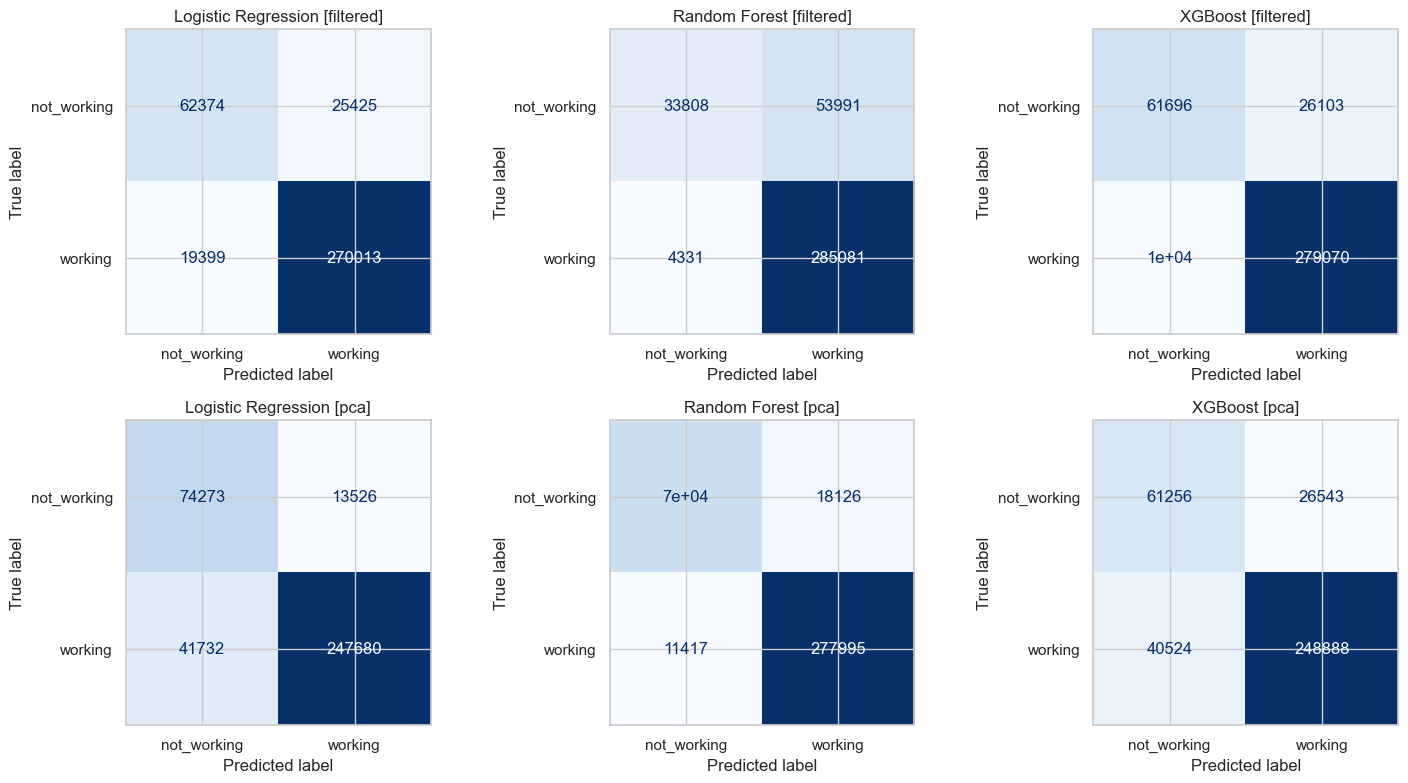

In [6]:
MODEL_KEYS = [("logreg", "Logistic Regression"),
              ("rf",     "Random Forest"),
              ("xgb",    "XGBoost")]

for name in ["filtered", "pca"]:
    y_te = splits[name]["y_test"]
    for model_key, model_label in MODEL_KEYS:
        print(f"=== [{name}] {model_label} ===")
        print(classification_report(y_te, preds[name][model_key][0], digits=3))
    print()

labels_order = sorted(splits["filtered"]["y_test"].unique())
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for r, name in enumerate(["filtered", "pca"]):
    y_te = splits[name]["y_test"]
    for c, (model_key, model_label) in enumerate(MODEL_KEYS):
        cm = confusion_matrix(y_te, preds[name][model_key][0], labels=labels_order)
        ConfusionMatrixDisplay(cm, display_labels=labels_order).plot(
            ax=axes[r, c], cmap="Blues", colorbar=False,
        )
        axes[r, c].set_title(f"{model_label} [{name}]")
plt.tight_layout()
plt.show()


### ROC curves (positive class = `not_working`)

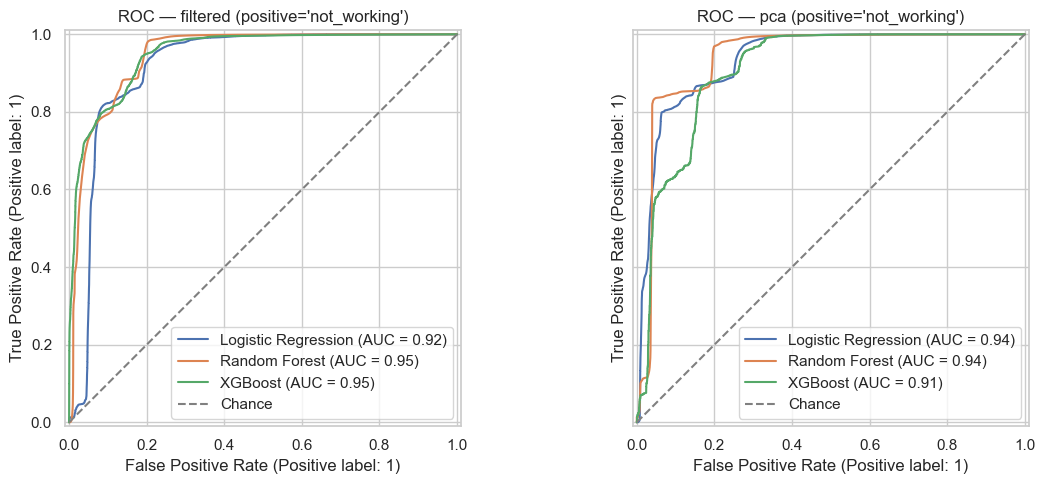

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
for ax, name in zip(axes, ["filtered", "pca"]):
    y_te = splits[name]["y_test"]
    y_true_bin = (y_te == POSITIVE_LABEL).astype(int)
    RocCurveDisplay.from_predictions(y_true_bin, preds[name]["logreg"][1],
                                     ax=ax, name="Logistic Regression")
    RocCurveDisplay.from_predictions(y_true_bin, preds[name]["rf"][1],
                                     ax=ax, name="Random Forest")
    RocCurveDisplay.from_predictions(y_true_bin, preds[name]["xgb"][1],
                                     ax=ax, name="XGBoost")
    ax.plot([0, 1], [0, 1], ls="--", color="grey", label="Chance")
    ax.set_title(f"ROC — {name} (positive='{POSITIVE_LABEL}')")
    ax.legend(loc="lower right")
plt.tight_layout()
plt.show()


## 5. Feature importance — side-by-side

Top row: filtered raw channels. Bottom row: PCA components.

- **Logistic-regression coefficients** — signed, on standardized features
  (red ⇒ pushes toward `not_working`, blue ⇒ toward `working`).
- **Random-forest impurity importance** — unsigned, non-linear contribution.

For the PCA row, consult `{SERIAL_NUMBER}_PCA_loadings.csv` to map the top
components back to original channels.


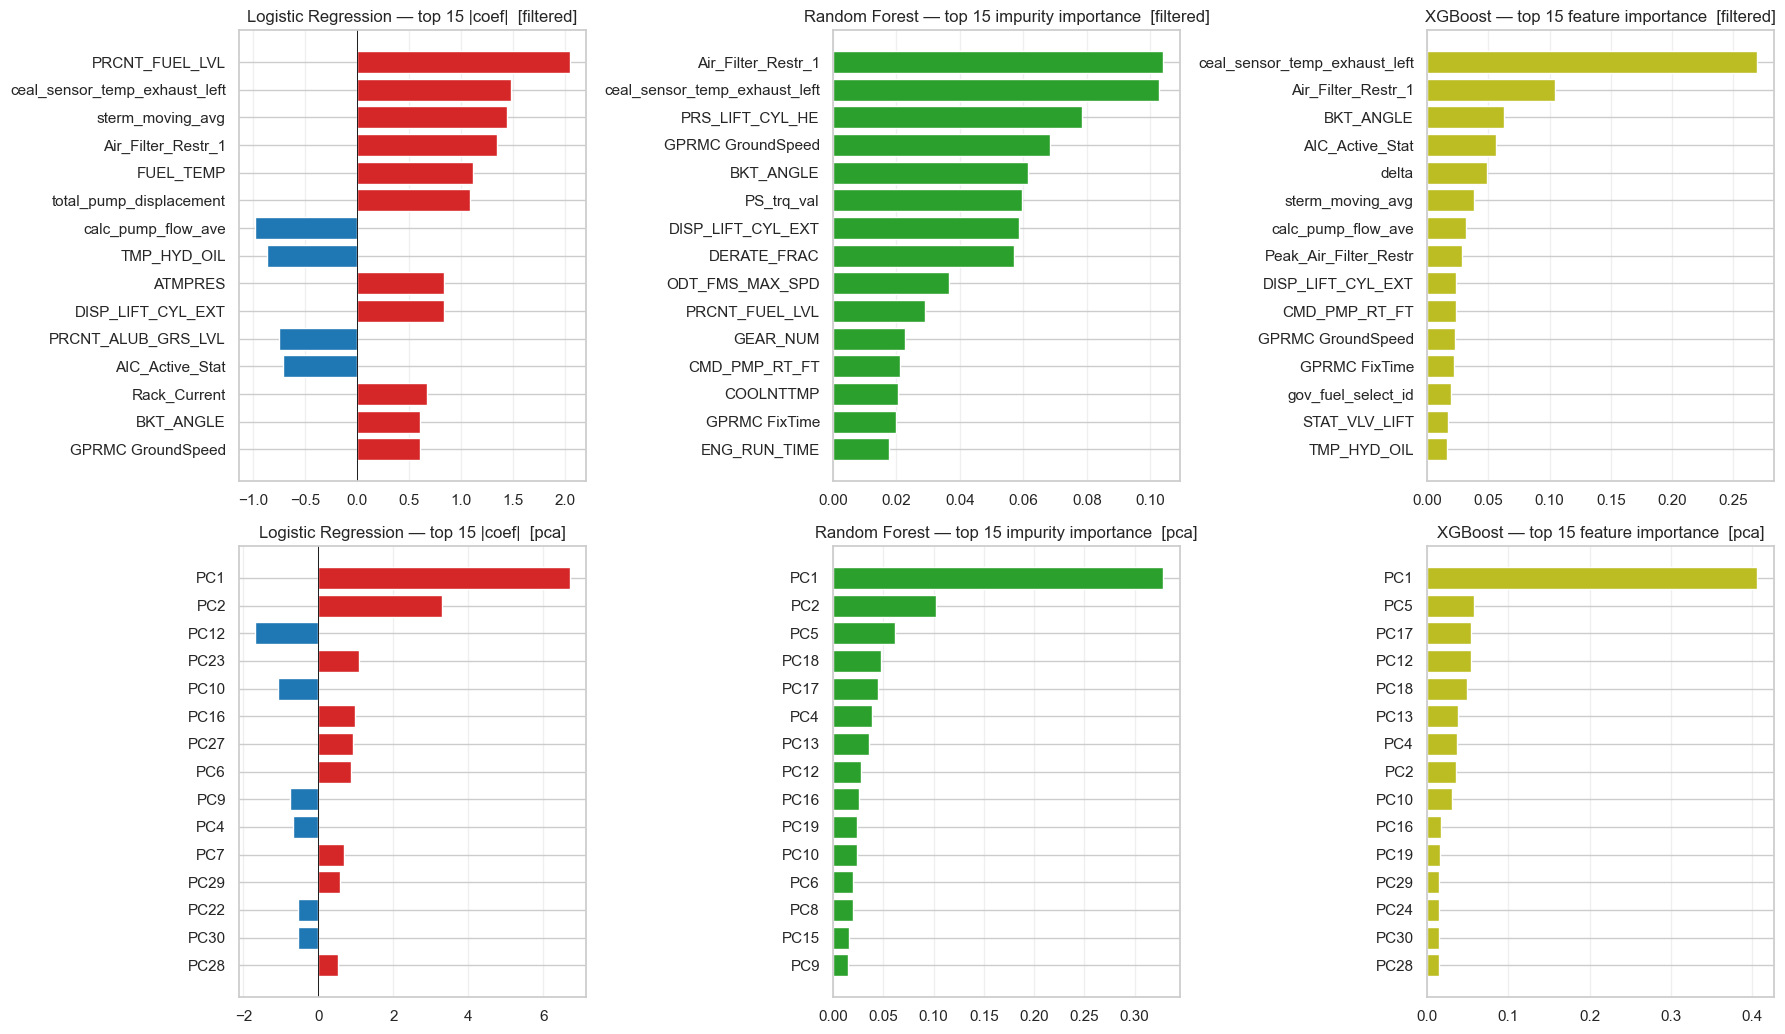

Top 20 — filtered features:


,logreg_coef,logreg_abs,rf_importance,xgb_importance
Air_Filter_Restr_1,1.3461,1.3461,0.1042,0.1043
ceal_sensor_temp_exhaust_left,1.4823,1.4823,0.1029,0.2697
PRS_LIFT_CYL_HE,-0.1102,0.1102,0.0784,0.0151
GPRMC GroundSpeed,0.6008,0.6008,0.0685,0.0228
BKT_ANGLE,0.6049,0.6049,0.0614,0.0630
PS_trq_val,0.0480,0.0480,0.0595,0.0033
DISP_LIFT_CYL_EXT,0.8338,0.8338,0.0585,0.0239
DERATE_FRAC,0.1462,0.1462,0.0571,0.0074
ODT_FMS_MAX_SPD,-0.0983,0.0983,0.0367,0.0038
PRCNT_FUEL_LVL,2.0488,2.0488,0.0291,0.0067


Top 20 — PCA components:


,logreg_coef,logreg_abs,rf_importance,xgb_importance
PC1,6.7172,6.7172,0.3286,0.4063
PC2,3.2894,3.2894,0.1029,0.0352
PC5,0.0326,0.0326,0.0619,0.0574
PC18,-0.0649,0.0649,0.0479,0.0497
PC17,-0.5042,0.5042,0.0447,0.0546
PC4,-0.6749,0.6749,0.0391,0.0364
PC13,-0.4739,0.4739,0.0358,0.0383
PC12,-1.6942,1.6942,0.0274,0.0541
PC16,0.9797,0.9797,0.0262,0.0171
PC19,-0.2988,0.2988,0.0242,0.0156


In [8]:
TOP_K = 15
importance_tables = {}

fig, axes = plt.subplots(2, 3, figsize=(18, 2 * max(4, TOP_K * 0.35)))

for r, name in enumerate(["filtered", "pca"]):
    feat_used = list(splits[name]["X_train"].columns)

    # Logistic-regression coefficients (signed)
    lr_clf = fitted[name]["logreg"].named_steps["clf"]
    pos_idx = list(lr_clf.classes_).index(POSITIVE_LABEL)
    coef = pd.Series(lr_clf.coef_[pos_idx], index=feat_used, name="logreg_coef")
    coef_sorted = coef.reindex(coef.abs().sort_values(ascending=False).index)

    # Random-forest impurity importance
    rf_imp = pd.Series(fitted[name]["rf"].feature_importances_,
                       index=feat_used, name="rf_importance")
    rf_imp_sorted = rf_imp.sort_values(ascending=False)

    # XGBoost gain-based importance (default: "weight"/"gain" per booster)
    xgb_imp = pd.Series(fitted[name]["xgb"].feature_importances_,
                        index=feat_used, name="xgb_importance")
    xgb_imp_sorted = xgb_imp.sort_values(ascending=False)

    top_coef = coef_sorted.head(TOP_K).iloc[::-1]
    axes[r, 0].barh(top_coef.index, top_coef.values,
                    color=["tab:red" if v > 0 else "tab:blue" for v in top_coef.values])
    axes[r, 0].set_title(f"Logistic Regression — top {TOP_K} |coef|  [{name}]")
    axes[r, 0].axvline(0, color="k", lw=0.7)
    axes[r, 0].grid(True, axis="x", alpha=0.3)

    top_rf = rf_imp_sorted.head(TOP_K).iloc[::-1]
    axes[r, 1].barh(top_rf.index, top_rf.values, color="tab:green")
    axes[r, 1].set_title(f"Random Forest — top {TOP_K} impurity importance  [{name}]")
    axes[r, 1].grid(True, axis="x", alpha=0.3)

    top_xgb = xgb_imp_sorted.head(TOP_K).iloc[::-1]
    axes[r, 2].barh(top_xgb.index, top_xgb.values, color="tab:olive")
    axes[r, 2].set_title(f"XGBoost — top {TOP_K} feature importance  [{name}]")
    axes[r, 2].grid(True, axis="x", alpha=0.3)

    importance_tables[name] = (
        pd.concat([coef.rename("logreg_coef"),
                   coef.abs().rename("logreg_abs"),
                   rf_imp,
                   xgb_imp], axis=1)
          .sort_values("rf_importance", ascending=False)
    )

plt.tight_layout()
plt.show()

print("Top 20 — filtered features:")
display(importance_tables["filtered"].head(20).round(4))

print("Top 20 — PCA components:")
display(importance_tables["pca"].head(20).round(4))


## 6. Under / overfitting diagnostic — learning curves (side-by-side)

Train and validation `f1_macro` as a function of training-set size, for both
models and both feature sets. We use `TimeSeriesSplit` so each fold respects
the chronological order. Top row: filtered features. Bottom row: PCA scores.


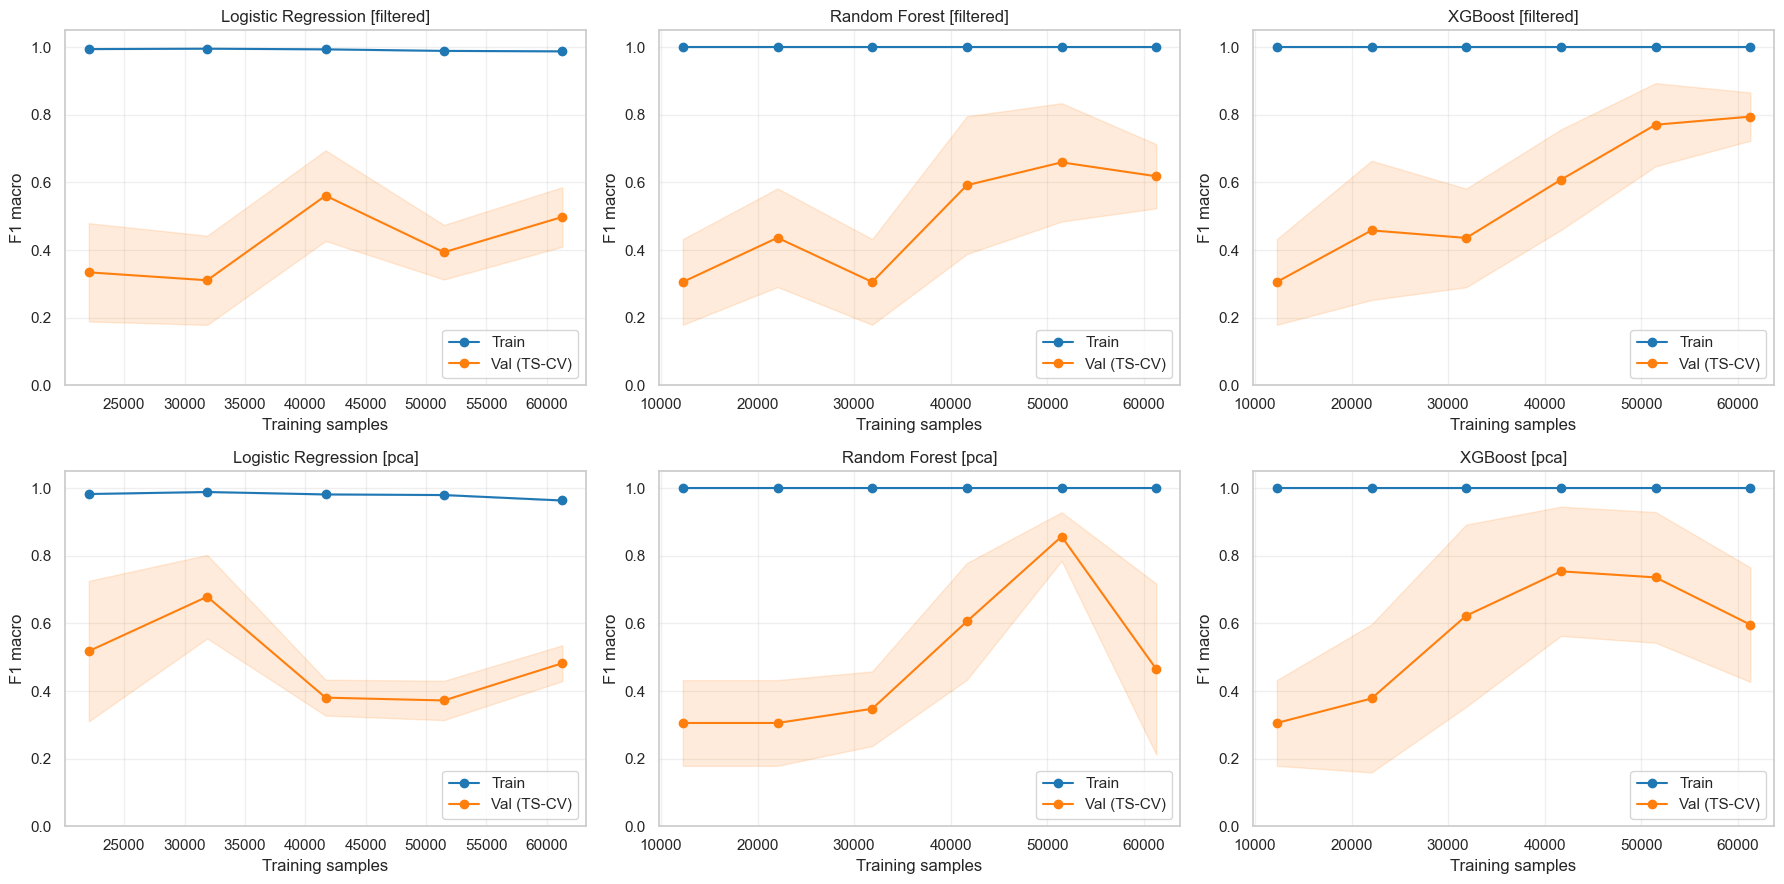

In [9]:
def plot_learning_curve(model, X, y, title, ax):
    sizes, train_sc, val_sc = learning_curve(
        model, X, y,
        cv=TimeSeriesSplit(n_splits=5),
        scoring="f1_macro",
        train_sizes=np.linspace(0.2, 1.0, 6),
        n_jobs=-1,
        shuffle=False,
    )
    ax.plot(sizes, train_sc.mean(axis=1), "o-", label="Train",  color="tab:blue")
    ax.plot(sizes, val_sc.mean(axis=1),   "o-", label="Val (TS-CV)", color="tab:orange")
    ax.fill_between(sizes,
                    train_sc.mean(axis=1) - train_sc.std(axis=1),
                    train_sc.mean(axis=1) + train_sc.std(axis=1),
                    alpha=0.15, color="tab:blue")
    ax.fill_between(sizes,
                    val_sc.mean(axis=1) - val_sc.std(axis=1),
                    val_sc.mean(axis=1) + val_sc.std(axis=1),
                    alpha=0.15, color="tab:orange")
    ax.set_title(title)
    ax.set_xlabel("Training samples")
    ax.set_ylabel("F1 macro")
    ax.set_ylim(0, 1.05)
    ax.legend(loc="lower right")
    ax.grid(True, alpha=0.3)


fig, axes = plt.subplots(2, 3, figsize=(18, 9))
for r, name in enumerate(["filtered", "pca"]):
    S = splits[name]
    # Fresh estimators (so learning_curve refits from scratch on each fold size)
    lr_pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=2_000,
                                   class_weight="balanced",
                                   random_state=RANDOM_STATE)),
    ])
    rf_est = RandomForestClassifier(
        n_estimators=200, n_jobs=-1,
        class_weight="balanced", random_state=RANDOM_STATE,
    )
    y_tr_bin = (S["y_train"] == POSITIVE_LABEL).astype(int)
    neg, pos = (y_tr_bin == 0).sum(), (y_tr_bin == 1).sum()
    spw = float(neg) / float(pos) if pos > 0 else 1.0
    xgb_est = XGBStringWrapper(
        n_estimators=300, max_depth=6, learning_rate=0.1,
        subsample=0.9, colsample_bytree=0.9,
        objective="binary:logistic", eval_metric="logloss",
        tree_method="hist", scale_pos_weight=spw,
        n_jobs=-1, random_state=RANDOM_STATE,
    )
    plot_learning_curve(lr_pipe, S["X_train"], S["y_train"],
                        f"Logistic Regression [{name}]", axes[r, 0])
    plot_learning_curve(rf_est, S["X_train"], S["y_train"],
                        f"Random Forest [{name}]",       axes[r, 1])
    plot_learning_curve(xgb_est, S["X_train"], S["y_train"],
                        f"XGBoost [{name}]",             axes[r, 2])
plt.tight_layout()
plt.show()


## 7. Final comparison and minimum acceptable performance

All models from both feature sets in one table, plus a bar chart of the key metric.

**Chosen primary metric: `f1_macro`** — the dataset is class-imbalanced
(`working` dominates), and from a maintenance standpoint both classes matter
(false positives waste service trips, false negatives miss downtime).
`f1_macro` averages F1 across classes without favouring the majority,
which makes it a fair business-aligned target.

**Minimum acceptable performance:** any candidate model must clearly beat the
*Dummy* baseline AND match-or-beat the *Keyswitch rule* on `f1_macro`. Until
that is true, the added complexity is not justified.


,acc_train,acc_test,bal_acc_test,f1_macro_test,precision_pos,recall_pos,f1_pos,roc_auc
model,,,,,,,,
Dummy (most_frequent),0.500,0.233,0.500,0.189,0.233,1.000,0.378,0.500
LogReg [filtered],0.933,0.881,0.822,0.830,0.763,0.710,0.736,0.918
RandomForest [filtered],1.000,0.845,0.685,0.722,0.886,0.385,0.537,0.947
XGBoost [filtered],1.000,0.903,0.833,0.855,0.856,0.703,0.772,0.950
LogReg [pca],0.917,0.854,0.851,0.814,0.640,0.846,0.729,0.935
RandomForest [pca],1.000,0.922,0.877,0.887,0.859,0.794,0.825,0.940
XGBoost [pca],0.999,0.822,0.779,0.764,0.602,0.698,0.646,0.908


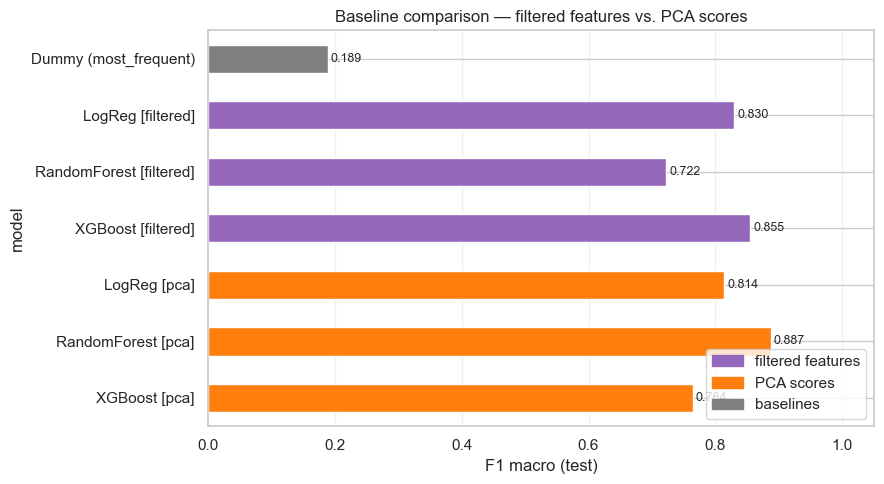


Saved combined baseline comparison to: C:\Users\alvarjl3\Documents\Repos\Downtime_Analysis\M9P00224_baseline_results.csv


In [10]:
summary = results_df.copy()
display(summary)

# Color bars by feature set for at-a-glance comparison
def _bar_color(model_name: str) -> str:
    if "[pca]" in model_name.lower():
        return "tab:orange"
    if "[filtered]" in model_name.lower():
        return "tab:purple"
    return "tab:grey"  # Dummy / Keyswitch baselines

colors = [_bar_color(m) for m in summary.index]

fig, ax = plt.subplots(figsize=(9, 5))
summary["f1_macro_test"].plot(kind="barh", ax=ax, color=colors)
ax.set_xlabel("F1 macro (test)")
ax.set_title("Baseline comparison — filtered features vs. PCA scores")
ax.invert_yaxis()
for i, v in enumerate(summary["f1_macro_test"].values):
    if np.isfinite(v):
        ax.text(v + 0.005, i, f"{v:.3f}", va="center", fontsize=9)
ax.set_xlim(0, 1.05)
ax.grid(True, axis="x", alpha=0.3)

# Manual legend
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color="tab:purple", label="filtered features"),
    Patch(color="tab:orange", label="PCA scores"),
    Patch(color="tab:grey",   label="baselines"),
], loc="lower right")

plt.tight_layout()
plt.show()

# Persist the combined comparison for the next stage
summary_out = Path(f"{SERIAL_NUMBER}_baseline_results.csv")
summary.to_csv(summary_out)
print(f"\nSaved combined baseline comparison to: {summary_out.resolve()}")


## 8. Conclusions

Answering the five guiding questions of this stage:

1. **Which baseline algorithm?** Dummy and three reference baselines (Dummy + Logistic RegressionX + Random Forest + XGBoost) 
   trained in parallel on the two feature representations produced in Avance 2
   (filtered raw channels and PCA scores).

2. **Feature importance?** Yes — Logistic-Regression coefficients give a signed
   view (which features push toward `not_working`) and the Random Forest gives
   an unsigned impurity importance. The side-by-side panels in §5 expose:
   - on **filtered features**, any channel with both `|coef| ≈ 0` and
     `rf_importance ≈ 0` is a candidate to drop in the next iteration of
     Avance 2;
   - on **PCA scores**, the dominant components can be mapped back to original
     channels via `{SERIAL_NUMBER}_PCA_loadings.csv`.

3. **Under / overfitting?** The 2×2 learning-curve grid in §6 makes the
   diagnostic explicit per (model × feature set):
   - Logistic Regression typically shows a very small train/CV gap → bias-limited.
   - Random Forest closes the gap as training size grows; a residual gap is
     expected because trees memorize.

4. **Right metric?** `f1_macro` (used in the §7 comparison) plus
   `balanced_accuracy` and the **recall of `not_working`** as business-critical
   secondary metrics — missing downtime events is the costliest mistake.

5. **Minimum acceptable performance?** Any future model must beats the **Dummy** classifier on `f1_macro` by a wide margin. Anything below that does not justify the complexity of a learned model over the existing onboard signal.

The exported `*_baseline_results.csv` is the reference card we will compare
every future model against — and now contains both representations in a single
table.
